In [100]:
# Thach Ta
# 1001744101

# Lab 7- Data Analysis


## Exercise 1: Reading

### HiggsML
In 2014, some of my colleagues from the ATLAS experiment put together a Higgs Machine Learning Challenge, which was hosted on [Kaggle](https://www.kaggle.com). Please read sections 1 and 3 (skip/skim 2) of [The HiggsML Technical Documentation](https://higgsml.lal.in2p3.fr/files/2014/04/documentation_v1.8.pdf). 

Kaggle is a platform for data science competitions, with cash awards for winners. Kaggle currently hosts over 50,000 public datasets and associated competitions. Later in the course we will look at a variety of problems hosted on Kaggle and similar platforms. 

### SUSY Dataset

For the next few labs we will use datasets used in the [first paper on Deep Learning in High Energy physics](https://arxiv.org/pdf/1402.4735.pdf). Please read up to the "Deep Learning" section (end of page 5). This paper demonstrates that Deep Neural Networks can learn from raw data the features that are typically used by physicists for searches for exotics particles. The authors provide the data they used for this paper. They considered two benchmark scenarios: Higgs and SUSY.

## Exercise 2: Download SUSY Dataset

The information about the dataset can be found at the [UCI Machine Learning Repository](https://archive.ics.uci.edu/ml/index.php). We'll start with the [SUSY Dataset](https://archive.ics.uci.edu/ml/datasets/SUSY). 

### Download
In a terminal, download the data directly from the source and then decompress it. For example:

* To download:
    * On Mac OS: 
    `curl http://archive.ics.uci.edu/ml/machine-learning-databases/00279/SUSY.csv.gz > SUSY.csv.gz`

    * In linux:
    `wget http://archive.ics.uci.edu/ml/machine-learning-databases/00279/SUSY.csv.gz`

* To uncompress:
`gunzip SUSY.csv.gz`

In [2]:
#!curl http://archive.ics.uci.edu/ml/machine-learning-databases/00279/SUSY.csv.gz > SUSY.csv.gz

In [3]:
#!rm SUSY.csv

In [4]:
#!gunzip SUSY.csv.gz

In [35]:
ls -lh

total 2.5G
-rw-r--r-- 1 tickertackers tickertackers 8.0M Apr  3 16:49 Lab.7.pdf
-rw-r--r-- 1 tickertackers tickertackers 1.5M Apr  3 20:35 Lab.7_Answers.ipynb
-rw-r--r-- 1 tickertackers tickertackers 228M Apr  3 20:37 SUSY-small.csv
-rw-r--r-- 1 tickertackers tickertackers 2.3G Apr  3 17:07 SUSY.csv
-rw-r--r-- 1 tickertackers tickertackers 3.9M Apr  3 16:57 SUSY.csv.gz~


The data is provided as a comma separated file.

In [36]:
filename="SUSY.csv"
# print out the first 5 lines using unix head command
!head -5  "SUSY.csv"

0.000000000000000000e+00,9.728614687919616699e-01,6.538545489311218262e-01,1.176224589347839355e+00,1.157156467437744141e+00,-1.739873170852661133e+00,-8.743090629577636719e-01,5.677649974822998047e-01,-1.750000417232513428e-01,8.100607395172119141e-01,-2.525521218776702881e-01,1.921887040138244629e+00,8.896374106407165527e-01,4.107718467712402344e-01,1.145620822906494141e+00,1.932632088661193848e+00,9.944640994071960449e-01,1.367815494537353516e+00,4.071449860930442810e-02
1.000000000000000000e+00,1.667973041534423828e+00,6.419061869382858276e-02,-1.225171446800231934e+00,5.061022043228149414e-01,-3.389389812946319580e-01,1.672542810440063477e+00,3.475464344024658203e+00,-1.219136357307434082e+00,1.295456290245056152e-02,3.775173664093017578e+00,1.045977115631103516e+00,5.680512785911560059e-01,4.819284379482269287e-01,0.000000000000000000e+00,4.484102725982666016e-01,2.053557634353637695e-01,1.321893453598022461e+00,3.775840103626251221e-01
1.000000000000000000e+00,4.4483992457389831

## Reducing the dataset

This is a rather large dataset. If you have trouble loading it, we can easily make a new file with less data.

Here we look at the size of the data

In [37]:
!ls -lh

total 2.5G
-rw-r--r-- 1 tickertackers tickertackers 8.0M Apr  3 16:49 Lab.7.pdf
-rw-r--r-- 1 tickertackers tickertackers 1.5M Apr  3 20:35 Lab.7_Answers.ipynb
-rw-r--r-- 1 tickertackers tickertackers 228M Apr  3 20:37 SUSY-small.csv
-rw-r--r-- 1 tickertackers tickertackers 2.3G Apr  3 17:07 SUSY.csv
-rw-r--r-- 1 tickertackers tickertackers 3.9M Apr  3 16:57 SUSY.csv.gz~


We see that we have 5 million datapoints.

In [38]:
!wc -l SUSY.csv

5000000 SUSY.csv


We create a new file of the first half million. This is sufficient for our needs in this lab:

In [39]:
!head -500000 SUSY.csv > SUSY-small.csv

In [40]:
ls -lh

total 2.5G
-rw-r--r-- 1 tickertackers tickertackers 8.0M Apr  3 16:49 Lab.7.pdf
-rw-r--r-- 1 tickertackers tickertackers 1.5M Apr  3 20:35 Lab.7_Answers.ipynb
-rw-r--r-- 1 tickertackers tickertackers 228M Apr  3 20:38 SUSY-small.csv
-rw-r--r-- 1 tickertackers tickertackers 2.3G Apr  3 17:07 SUSY.csv
-rw-r--r-- 1 tickertackers tickertackers 3.9M Apr  3 16:57 SUSY.csv.gz~


In [41]:
! wc -l SUSY-small.csv

500000 SUSY-small.csv


Use this file for the rest of the lab to make this run faster.

### First Look

Each row represents a LHC collision event. Each column contains some observable from that event. The variable names are ([based on documentation](https://archive.ics.uci.edu/ml/datasets/SUSY)):

In [42]:
VarNames=["signal", "l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", "l_2_phi", "MET", "MET_phi", "MET_rel", "axial_MET", "M_R", "M_TR_2", "R", "MT2", "S_R", "M_Delta_R", "dPhi_r_b", "cos_theta_r1"]

Some of these variables represent the "raw" kinematics of the observed final state particles, while others are "features" that are derived from these raw quantities:

In [43]:
RawNames=["l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", "l_2_phi", "MET", "MET_phi"]
FeatureNames=list(set(VarNames[1:]).difference(RawNames))

In [44]:
RawNames

['l_1_pT',
 'l_1_eta',
 'l_1_phi',
 'l_2_pT',
 'l_2_eta',
 'l_2_phi',
 'MET',
 'MET_phi']

In [45]:
FeatureNames

['MET_rel',
 'M_TR_2',
 'axial_MET',
 'MT2',
 'M_Delta_R',
 'S_R',
 'dPhi_r_b',
 'R',
 'M_R',
 'cos_theta_r1']

We will use pandas to read in the file, and matplotlib to make plots. The following ensures pandas is installed and sets everything up:

In [46]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

Now we can read the data into a pandas dataframe:

In [47]:
filename = "SUSY.csv"
df = pd.read_csv(filename, dtype='float64', names=VarNames)

You can see the data in Jupyter by just evaluateing the dataframe:

In [48]:
df

,signal,l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi,MET,MET_phi,MET_rel,axial_MET,M_R,M_TR_2,R,MT2,S_R,M_Delta_R,dPhi_r_b,cos_theta_r1
0,0.0,0.972861,0.653855,1.176225,1.157156,-1.739873,-0.874309,0.567765,-0.175000,0.810061,-0.252552,1.921887,0.889637,0.410772,1.145621,1.932632,0.994464,1.367815,0.040714
1,1.0,1.667973,0.064191,-1.225171,0.506102,-0.338939,1.672543,3.475464,-1.219136,0.012955,3.775174,1.045977,0.568051,0.481928,0.000000,0.448410,0.205356,1.321893,0.377584
2,1.0,0.444840,-0.134298,-0.709972,0.451719,-1.613871,-0.768661,1.219918,0.504026,1.831248,-0.431385,0.526283,0.941514,1.587535,2.024308,0.603498,1.562374,1.135454,0.180910
3,1.0,0.381256,-0.976145,0.693152,0.448959,0.891753,-0.677328,2.033060,1.533041,3.046260,-1.005285,0.569386,1.015211,1.582217,1.551914,0.761215,1.715464,1.492257,0.090719
4,1.0,1.309996,-0.690089,-0.676259,1.589283,-0.693326,0.622907,1.087562,-0.381742,0.589204,1.365479,1.179295,0.968218,0.728563,0.000000,1.083158,0.043429,1.154854,0.094859
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4999995,1.0,0.853325,-0.961783,-1.487277,0.678190,0.493580,1.647969,1.843867,0.276954,1.025105,-1.486535,0.892879,1.684429,1.674084,3.366298,1.046707,2.646649,1.389226,0.364599
4999996,0.0,0.951581,0.139370,1.436884,0.880440,-0.351948,-0.740852,0.290863,-0.732360,0.001360,0.257738,0.802871,0.545319,0.602730,0.002998,0.748959,0.401166,0.443471,0.239953
4999997,0.0,0.840389,1.419162,-1.218766,1.195631,1.695645,0.663756,0.490888,-0.509186,0.704289,0.045744,0.825015,0.723530,0.778236,0.752942,0.838953,0.614048,1.210595,0.026692
4999998,1.0,1.784218,-0.833565,-0.560091,0.953342,-0.688969,-1.428233,2.660703,-0.861344,2.116892,2.906151,1.232334,0.952444,0.685846,0.000000,0.781874,0.676003,1.197807,0.093689


The first column stores the "truth" label of whether an event was signal or not. Pandas makes it easy to create dataframes that store only the signal or background events:

In [49]:
df_sig=df[df.signal==1]
df_bkg=df[df.signal==0]

The following example plots the signal and background distributions of every variable. Note that we use VarNames[1:] to skip the first variable, which was the true label.

l_1_pT


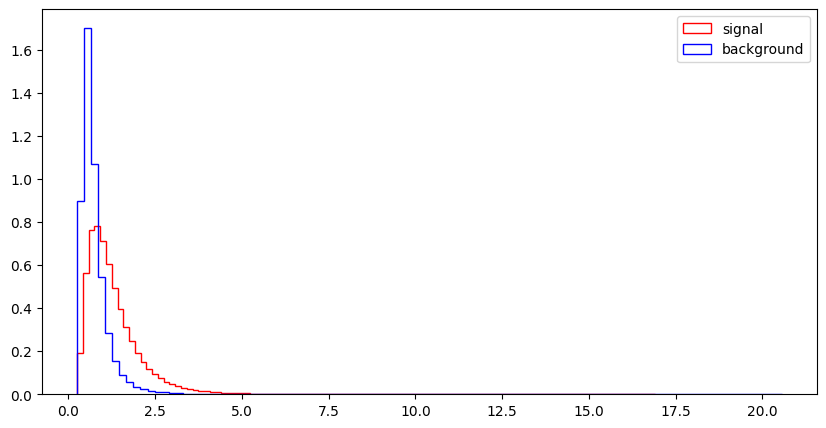

l_1_eta


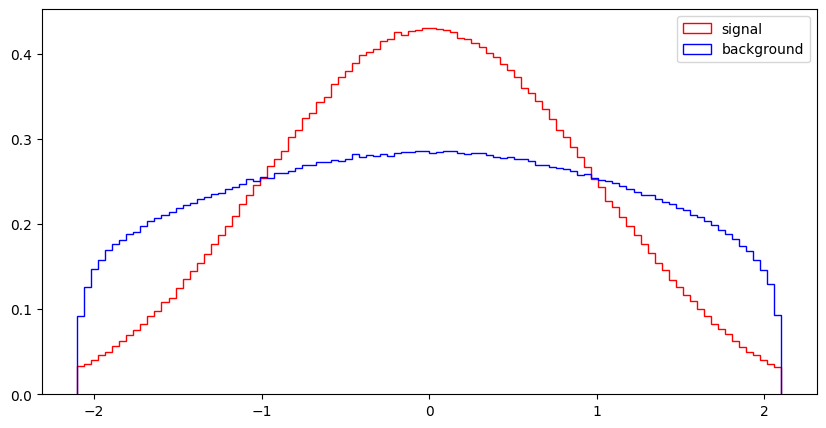

l_1_phi


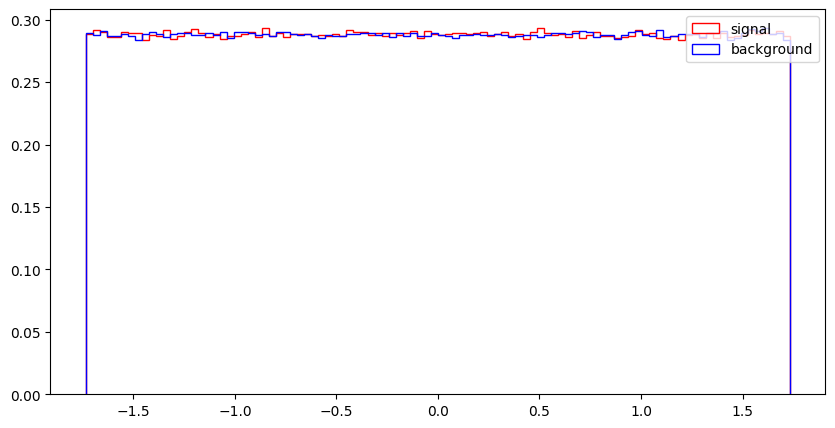

l_2_pT


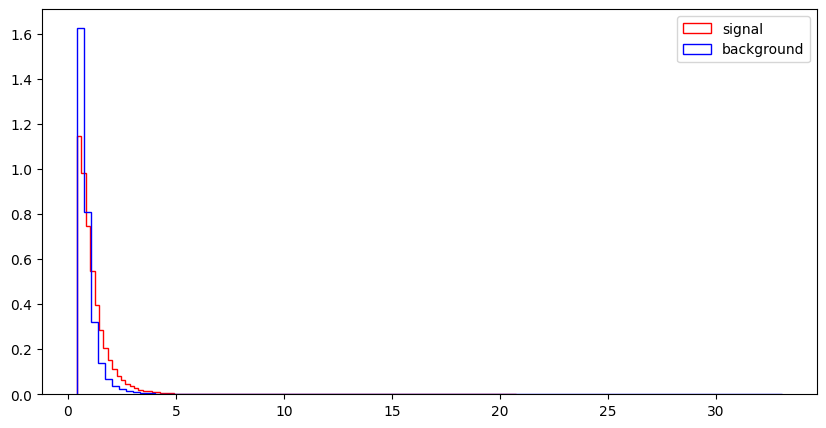

l_2_eta


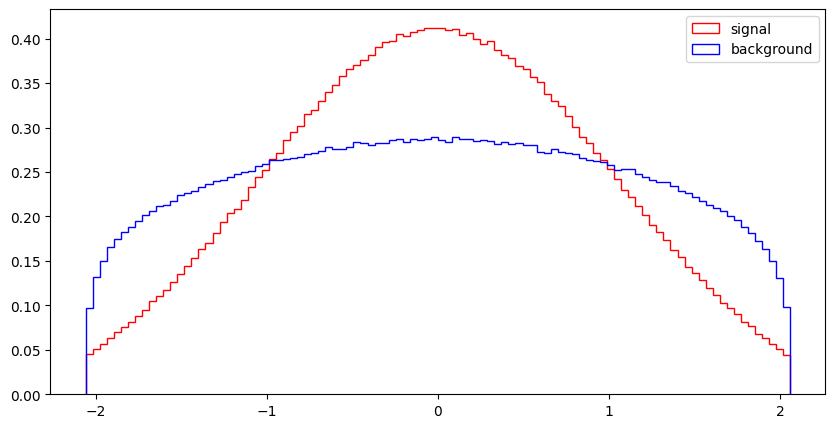

l_2_phi


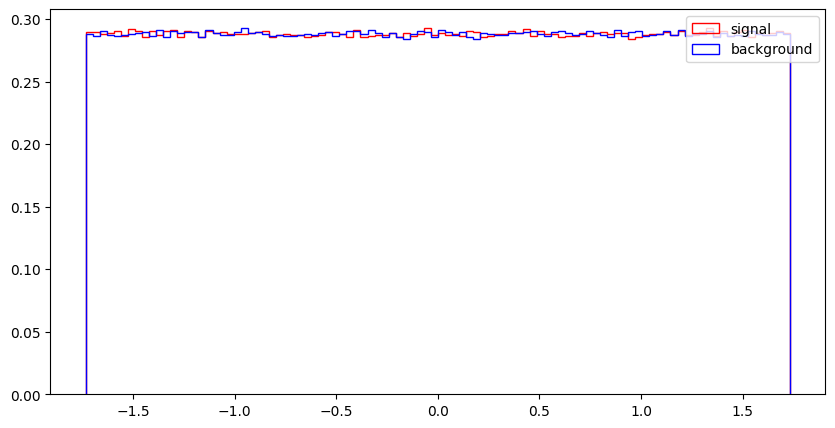

MET


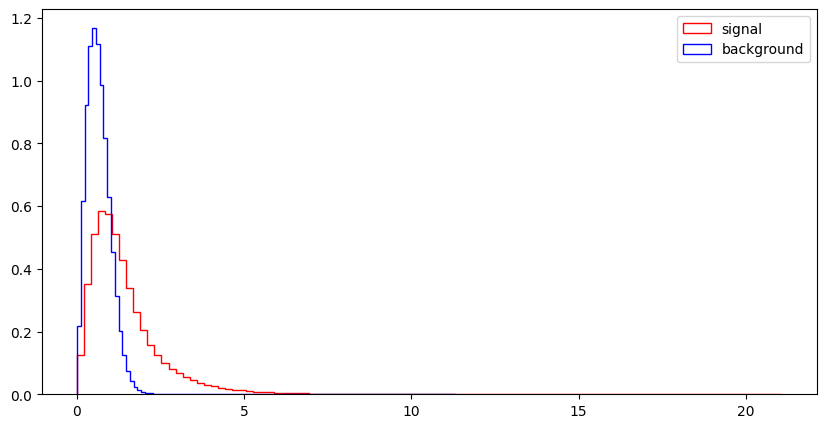

MET_phi


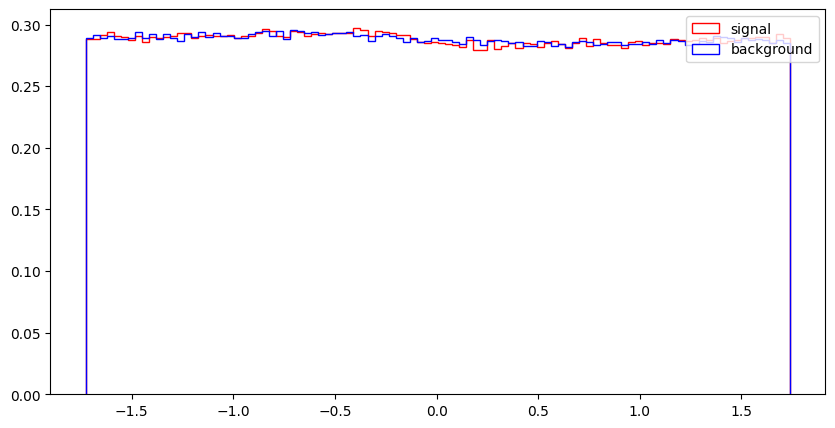

MET_rel


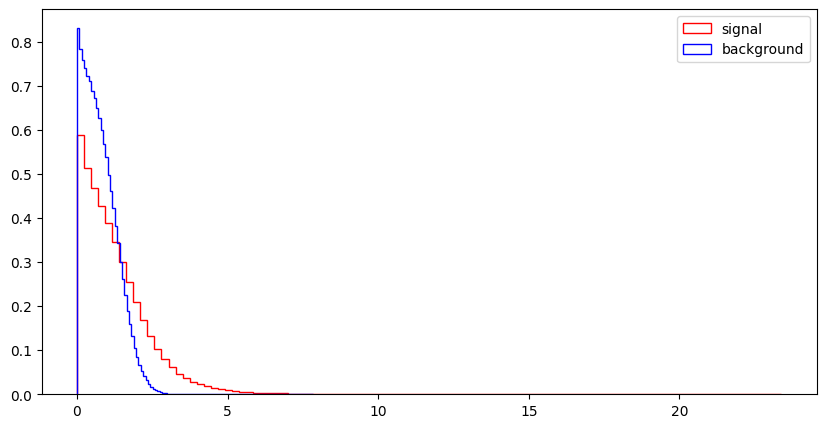

axial_MET


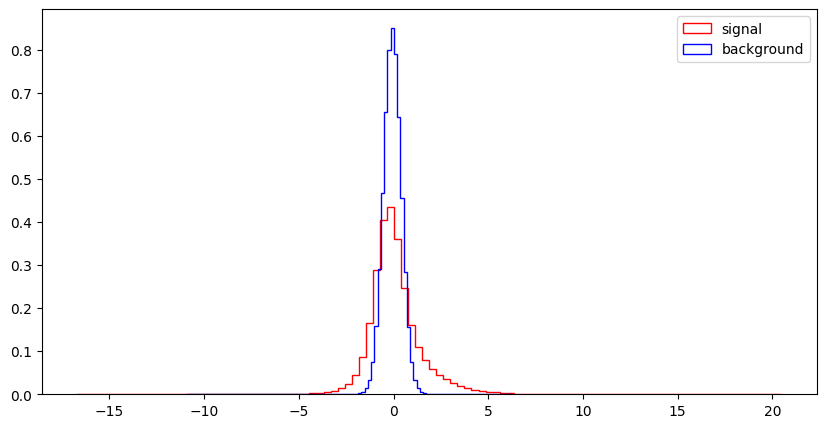

M_R


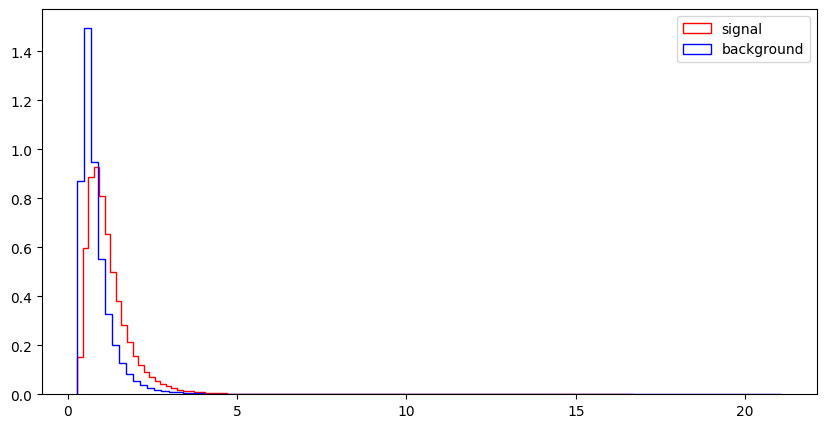

M_TR_2


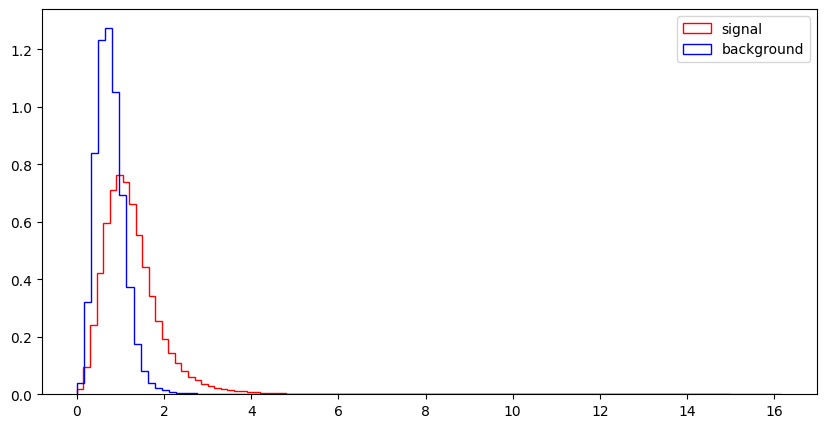

R


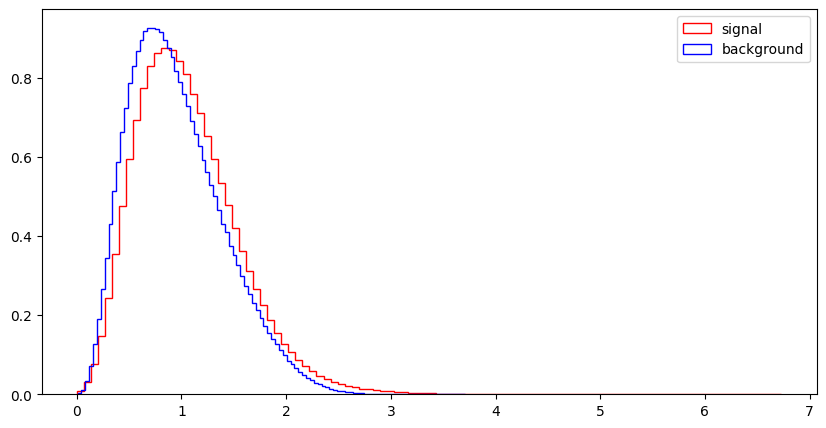

MT2


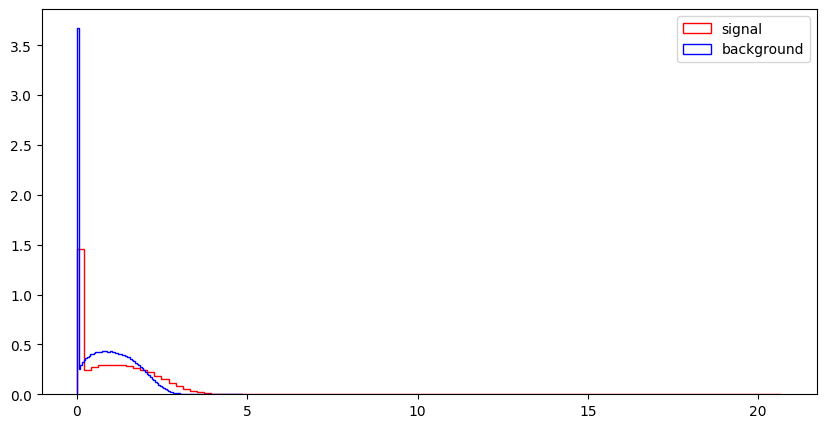

S_R


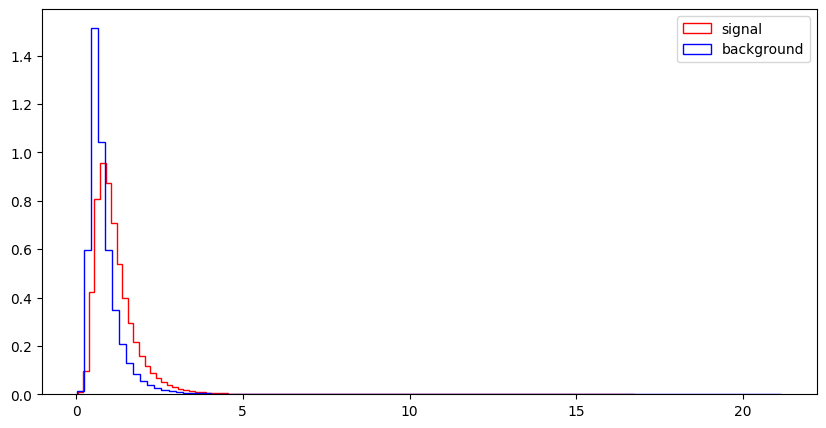

M_Delta_R


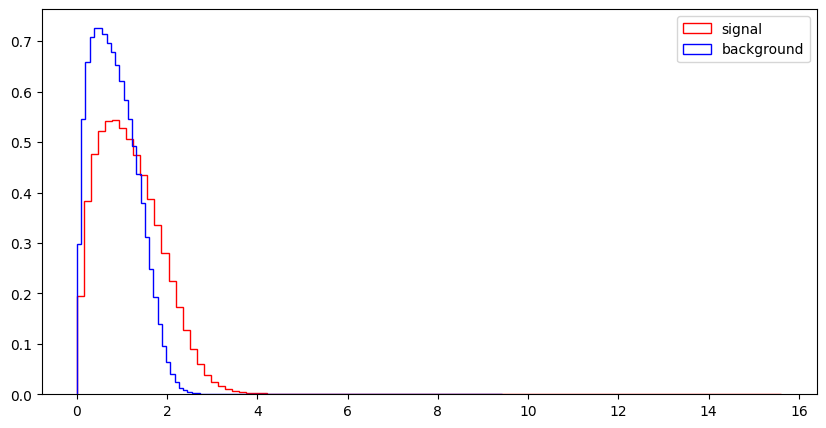

dPhi_r_b


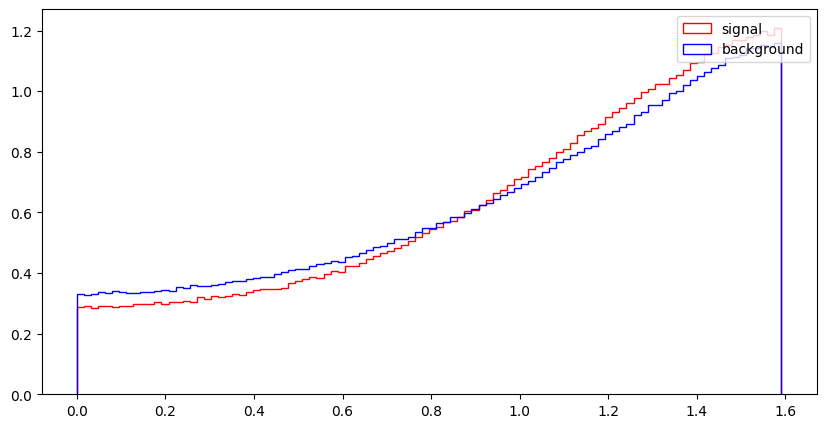

cos_theta_r1


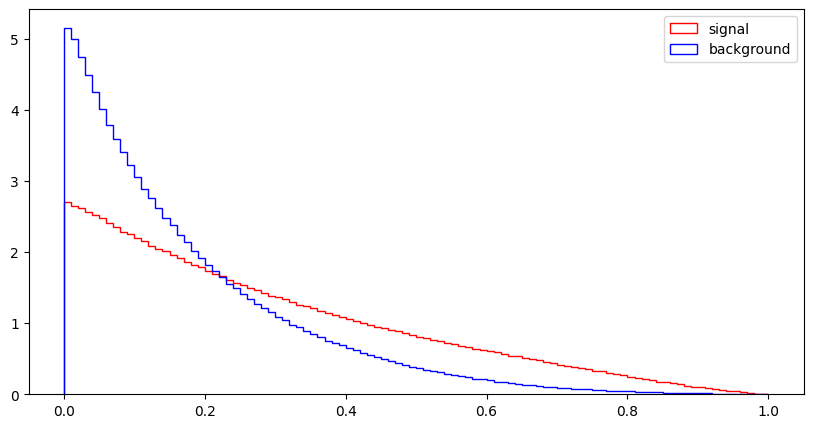

In [50]:
import numpy as np
for var in VarNames[1:]:
    print (var)
    plt.figure(figsize=(10,5))
    plt.hist(np.array(df_sig[var]),bins=100,histtype="step", color="red",label="signal",density=1, stacked=True)
    plt.hist(np.array(df_bkg[var]),bins=100,histtype="step", color="blue", label="background",density=1, stacked=True)
    plt.legend(loc='upper right')
    plt.show()

## Exercise 3: Make nice figures

Now use `matplotlib` to reproduce as closely as you can figures 5 and 6 from the paper. This exercise is intended to get you to familiarize yourself with making nicely formatted `matplotlib` figures with multiple plots. Note that the plots in the paper are actually wrong!

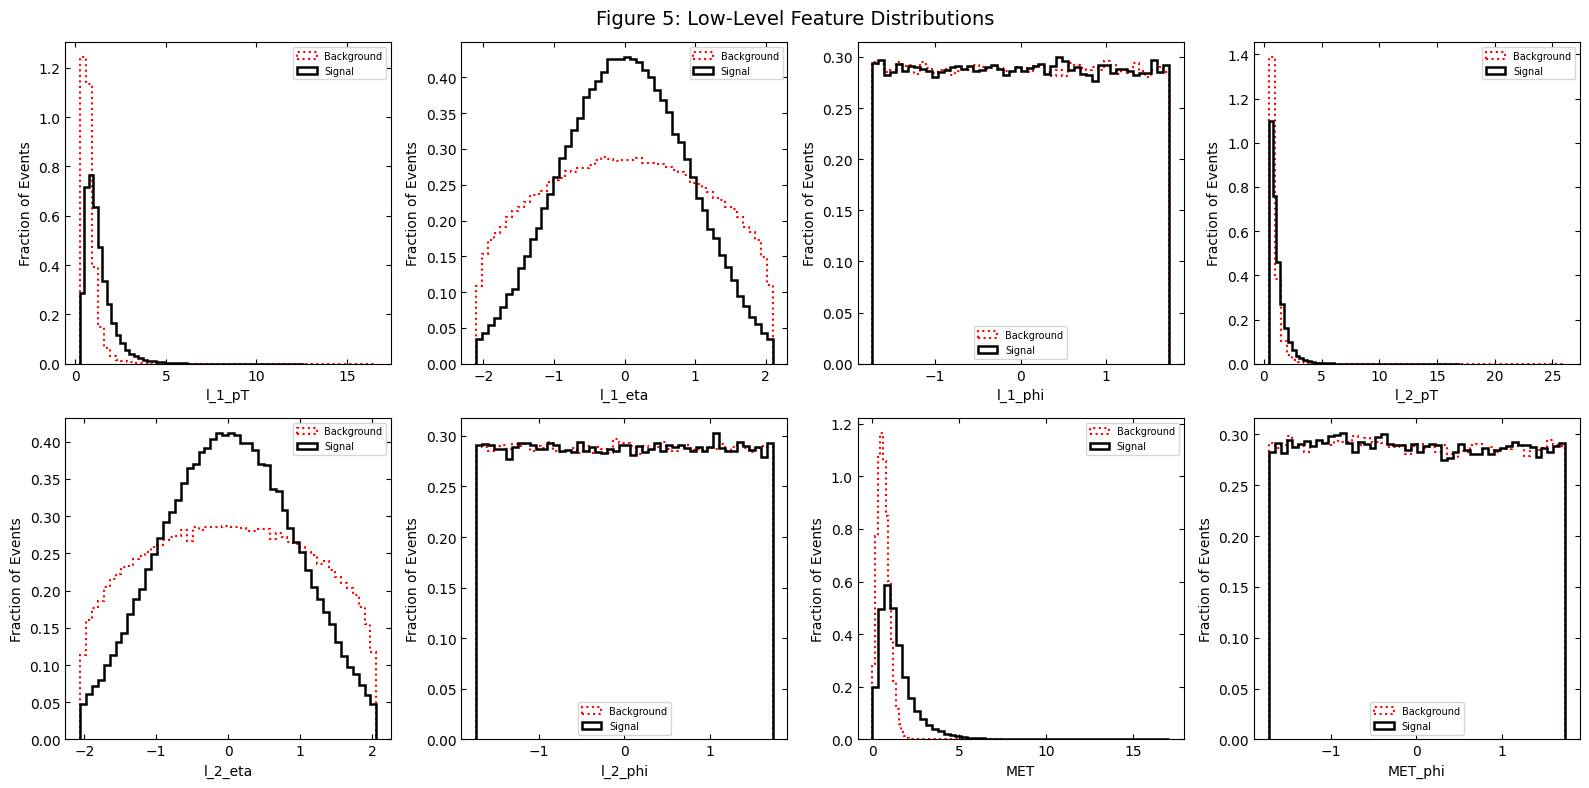

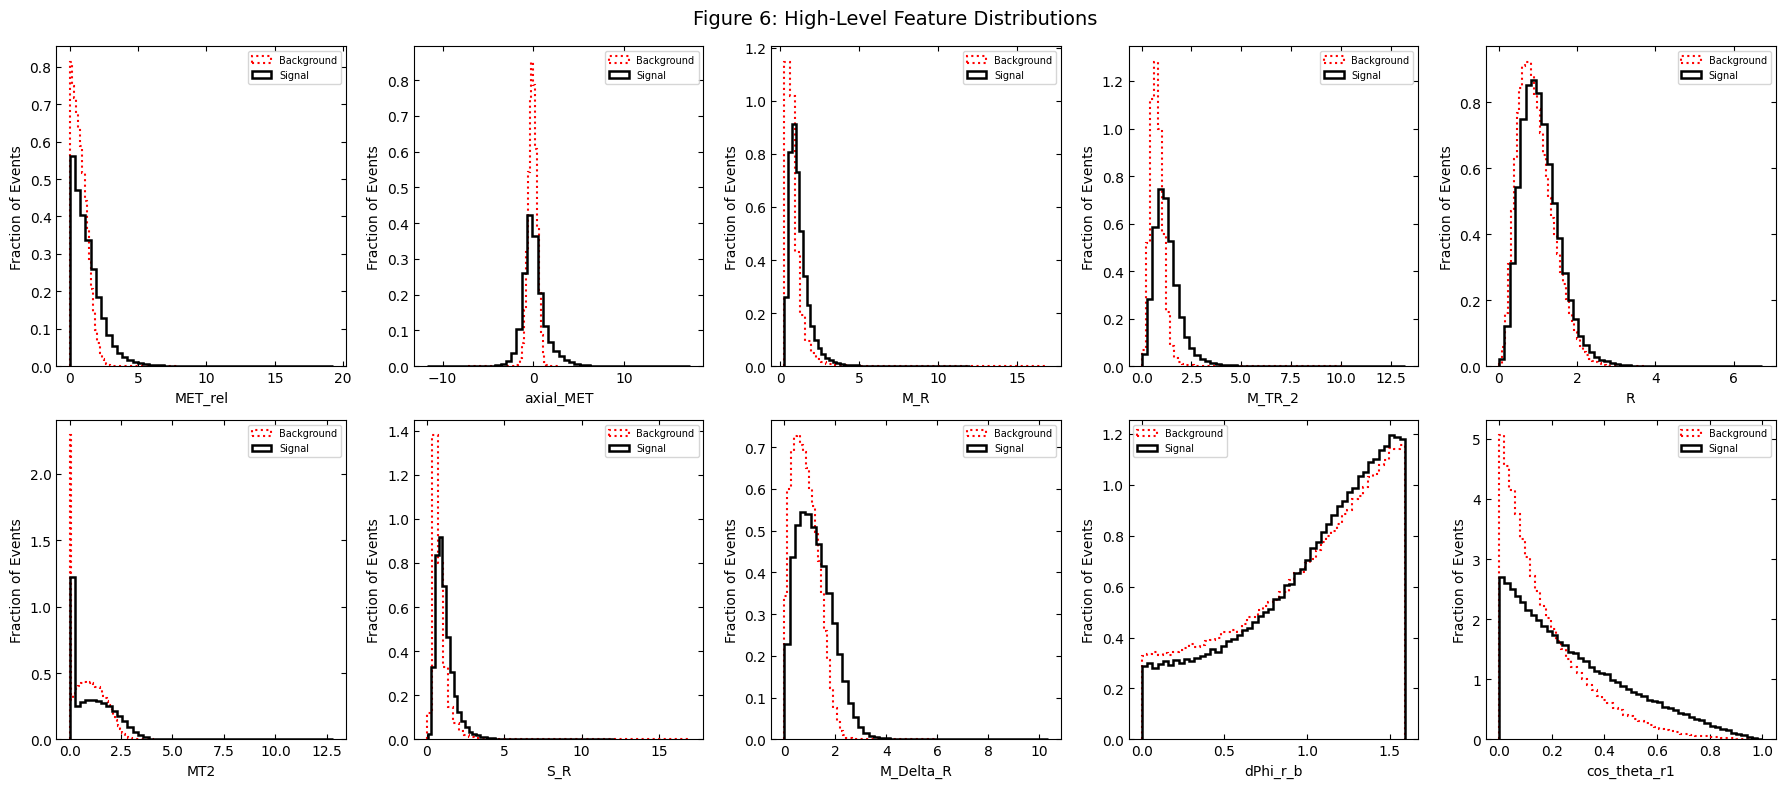

In [51]:
# Setting column names for the culled SUSY dataset
columns = [
    "signal", "l_1_pT", "l_1_eta", "l_1_phi",
    "l_2_pT", "l_2_eta", "l_2_phi",
    "MET", "MET_phi", "MET_rel",
    "axial_MET", "M_R", "M_TR_2", "R",
    "MT2", "S_R", "M_Delta_R", "dPhi_r_b", "cos_theta_r1"
]

# Setting the column names into the smaller dataset
df = pd.read_csv("SUSY-small.csv", names=columns)

# Separating feature by low vs. high based on dataset description
low_features = ["l_1_pT", "l_1_eta", "l_1_phi", "l_2_pT", "l_2_eta", "l_2_phi", "MET", "MET_phi"]
high_features = ["MET_rel", "axial_MET", "M_R", "M_TR_2", "R", "MT2", "S_R", "M_Delta_R", "dPhi_r_b", "cos_theta_r1"]

# Splitting signal vs. background
signal = df[df["signal"] == 1]
background = df[df["signal"] == 0]

# Helper function:
def plot_feature(ax, sig, bkg, feature):

    # Histogram formation for the background
    ax.hist(
        bkg[feature],
        bins=50,
        density=True,
        histtype="step",
        color="red", # Red to follow paper
        linestyle="dotted", # Dotted to follow paper
        linewidth=1.5,
        label="Background"
    )

    # Histogram formation for the signal
    ax.hist(
        sig[feature],
        bins=50,
        density=True,
        histtype="step",
        color="black",
        linewidth=1.8,
        label="Signal"
    )

    ax.set_xlabel(feature)
    ax.set_ylabel("Fraction of Events")

    ax.tick_params(direction="in", top=True, right=True)
    ax.legend(fontsize=7)

# ==========================================================
# FIG. 5: Low-level input features for SUSY bench-mark.
# ==========================================================
# Setting subplots for multiple graphs
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

# Loop to get associated feature level to plot
for i, feature in enumerate(low_features):
    plot_feature(axes[i], signal, background, feature)

fig.suptitle("Figure 5: Low-Level Feature Distributions", fontsize=14)
plt.tight_layout()
plt.show()

# ==========================================================
# FIG. 6: High-level input features for SUSY bench-mark.
# ==========================================================
# Same as FIG. 5, but with high_features
fig, axes = plt.subplots(2, 5, figsize=(18, 8))
axes = axes.flatten()

for i, feature in enumerate(high_features):
    plot_feature(axes[i], signal, background, feature)

fig.suptitle("Figure 6: High-Level Feature Distributions", fontsize=14)
plt.tight_layout()
plt.show()

## Exercise 4: Correlation

### Exercise 4.1

#### Part a
Write a function that creates pair plots and use it to compare variables in the SUSY sample, separately for low and high-level features. Refer to Lecture 13 for details. Do not use `seaborn`.

#### Part b
Making these plots can be slow because creating each plot initiates a full loop over the data. Make at least one modification to your function in part a to speed it up. Can you propose a different method of creating histograms that would speed up making such pair plots?

#### Part c
Which observables appear to be best for separating signal from background?

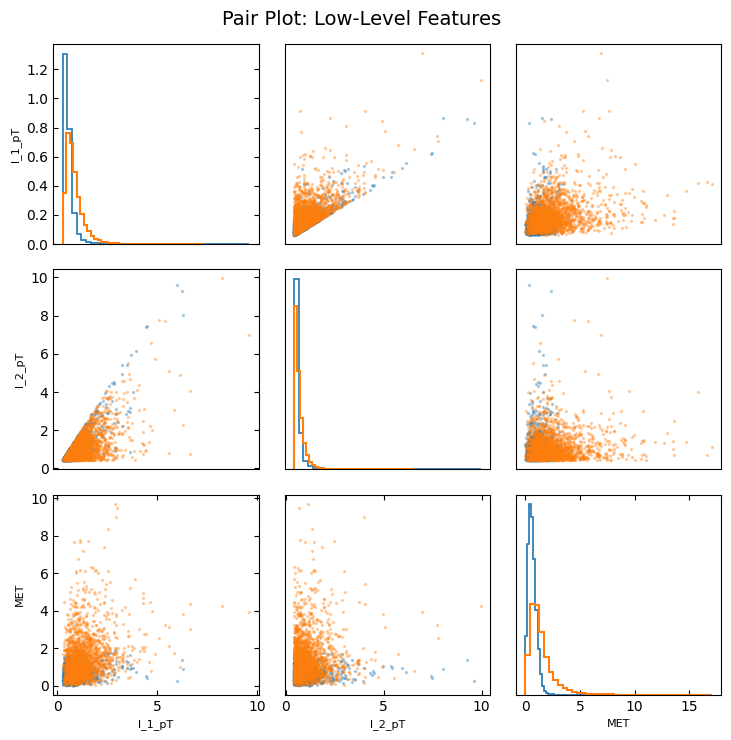

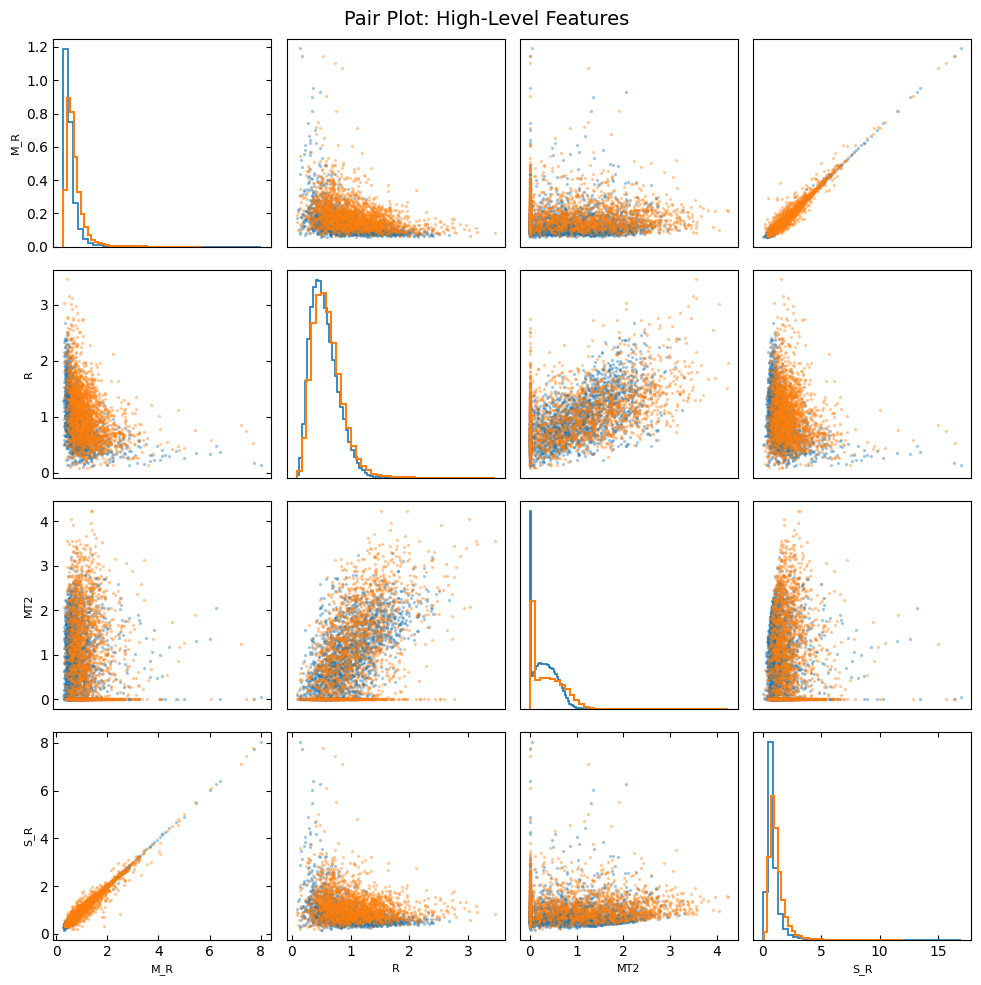

In [52]:
# Part b): To speed up the pair plots, I decided to grab only a sample from the dataset as well as using only a couple features instead of all of them
# Part c): As a result, it seems that MET, MT2, and S_R might be best for separating signal from background.
# -------------------------------
# Function to make scatter plots
def compare_scatter(sig, bkg, x_feature, y_feature, make_legend=False):
    # Using samples for making the scatter plots instead of all the data for faster processing
    sig_sample = sig.sample(2000, random_state=0)
    bkg_sample = bkg.sample(2000, random_state=0)

    # Scatter plot for background
    plt.scatter(
        bkg_sample[x_feature],
        bkg_sample[y_feature],
        s=2,
        alpha=0.3,
        label="Background" if make_legend else None
    )

    # Scatter plot for signal
    plt.scatter(
        sig_sample[x_feature],
        sig_sample[y_feature],
        s=2,
        alpha=0.3,
        label="Signal" if make_legend else None
    )

    if make_legend:
        plt.legend(fontsize=8)

    plt.tick_params(direction="in", top=True, right=True)

# Function to make histogram distributions:
def compare_distributions(sig, bkg, feature):
    # Background histograms
    plt.hist(
        bkg[feature],
        bins=40,
        density=True,
        histtype="step",
        linewidth=1.2
    )
    # Signal histograms
    plt.hist(
        sig[feature],
        bins=40,
        density=True,
        histtype="step",
        linewidth=1.5
    )

    plt.tick_params(direction="in", top=True, right=True)

# Function to make pair plot
def pair_plot(sig, bkg, features, title):

    # Getting features
    n_columns = len(features)
    plt.figure(figsize=(2.5 * n_columns, 2.5 * n_columns))

    # Looping features to make graphs
    plot_i = 0
    for i, y_var_name in enumerate(features):
        for j, x_var_name in enumerate(features):

            plot_i += 1
            plt.subplot(n_columns, n_columns, plot_i)

            make_legend = (plot_i == 1)

            if i == j:
                compare_distributions(sig, bkg, x_var_name)
            else:
                compare_scatter(sig, bkg, x_var_name, y_var_name, make_legend)

            # Axis labeling
            if i == n_columns - 1:
                plt.xlabel(x_var_name, fontsize=8)
            else:
                plt.xticks([])

            if j == 0:
                plt.ylabel(y_var_name, fontsize=8)
            else:
                plt.yticks([])

    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()

# Low-level
pair_plot(signal, background,
          ["l_1_pT", "l_2_pT", "MET"],
          "Pair Plot: Low-Level Features")

# High-level
pair_plot(signal, background,
    ["M_R", "R", "MT2", "S_R"],
    "Pair Plot: High-Level Features"
)

### Exercise 4.2

#### Part a
Install [tabulate](https://github.com/astanin/python-tabulate). 

#### Part b
Use numpy to compute the [covariance matrix](https://numpy.org/doc/stable/reference/generated/numpy.cov.html) and [correlation matrix](https://numpy.org/doc/stable/reference/generated/numpy.corrcoef.html) between all observabes, and separately between low and high-level features.

#### Part c
Use tabulate to create a well formatted table of the covariance and correlation matrices, with nice headings and appropriate significant figures. Embed the table into this notebook.

#### Part d
Write a function that takes a dataset and appropriate arguments and performs steps b and c.  

Hint: Example code for embedding a `tabulate` table into a notebook:

In [53]:
from IPython.display import HTML, display
import tabulate
table = [["A",1,2],
        ["C",3,4],
        ["D",5,6]]
display(HTML(tabulate.tabulate(table, tablefmt='html', headers=["X","Y","Z"])))

X,Y,Z
A,1,2
C,3,4
D,5,6


In [24]:
# Part a)
# tabulate installed

In [54]:
# Part b)
# Drop label column
X = df.drop(columns=["signal"]).values

# Numpy functions to get covariance and correlation matrixces
cov_matrix = np.cov(X, rowvar=False)
corr_matrix = np.corrcoef(X, rowvar=False)

# Getting low-level and high-level values
X_low = df[low_features].values
X_high = df[high_features].values

# Low-level value matrices
cov_low = np.cov(X_low, rowvar=False)
corr_low = np.corrcoef(X_low, rowvar=False)

# High-level value matrices
cov_high = np.cov(X_high, rowvar=False)
corr_high = np.corrcoef(X_high, rowvar=False)

In [55]:
# Part c)
from IPython.display import HTML, display
import tabulate

def display_matrix(matrix, feature_names, title):

    # Round for readability
    matrix_rounded = np.round(matrix, 3)

    # Forming matrix
    table = []
    for i, row in enumerate(matrix_rounded):
        table.append([feature_names[i]] + list(row))

    # Titling
    headers = [""] + feature_names

    # Displaying everything
    print(title)
    display(HTML(tabulate.tabulate(
        table,
        headers=headers,
        tablefmt="html"
    )))

# Displaying matrices for low-level
display_matrix(cov_low, low_features, "Covariance Matrix (Low-Level)")
display_matrix(corr_low, low_features, "Correlation Matrix (Low-Level)")
# Displaying matrices for high-level
display_matrix(cov_high, high_features, "Covariance Matrix (High-Level)")
display_matrix(corr_high, high_features, "Correlation Matrix (High-Level)")

Covariance Matrix (Low-Level)


,l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi,MET,MET_phi
l_1_pT,0.467,-0,0,0.305,-0,0.001,0.228,-0.001
l_1_eta,-0,1.004,-0.001,-0,0.408,-0.001,-0.002,-0.001
l_1_phi,0,-0.001,1.004,0.001,0,-0.267,0.001,-0.185
l_2_pT,0.305,-0,0.001,0.425,-0.001,0,0.079,-0.002
l_2_eta,-0,0.408,0,-0.001,1.006,0,0,-0
l_2_phi,0.001,-0.001,-0.267,0,0,1.004,-0,-0.035
MET,0.228,-0.002,0.001,0.079,0,-0,0.762,-0.003
MET_phi,-0.001,-0.001,-0.185,-0.002,-0,-0.035,-0.003,1.003


Correlation Matrix (Low-Level)


,l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi,MET,MET_phi
l_1_pT,1,-0.001,0,0.684,-0.001,0.001,0.383,-0.001
l_1_eta,-0.001,1,-0.001,-0,0.406,-0.001,-0.002,-0.001
l_1_phi,0,-0.001,1,0.002,0,-0.266,0.001,-0.184
l_2_pT,0.684,-0,0.002,1,-0.001,0,0.14,-0.002
l_2_eta,-0.001,0.406,0,-0.001,1,0,0,-0
l_2_phi,0.001,-0.001,-0.266,0,0,1,-0,-0.035
MET,0.383,-0.002,0.001,0.14,0,-0,1,-0.003
MET_phi,-0.001,-0.001,-0.184,-0.002,-0,-0.035,-0.003,1


Covariance Matrix (High-Level)


,MET_rel,axial_MET,M_R,M_TR_2,R,MT2,S_R,M_Delta_R,dPhi_r_b,cos_theta_r1
MET_rel,0.79,-0.12,0.044,0.302,0.249,0.409,0.082,0.415,0.146,0.055
axial_MET,-0.12,1.005,0.017,-0.185,-0.181,-0.461,-0.041,-0.233,-0.025,-0.054
M_R,0.044,0.017,0.392,0.21,-0.113,-0.037,0.38,0.074,-0.029,-0.014
M_TR_2,0.302,-0.185,0.21,0.338,0.104,0.189,0.228,0.242,0.058,0.052
R,0.249,-0.181,-0.113,0.104,0.222,0.232,-0.083,0.165,0.087,0.058
MT2,0.409,-0.461,-0.037,0.189,0.232,0.738,-0.011,0.433,0.021,0.045
S_R,0.082,-0.041,0.38,0.228,-0.083,-0.011,0.382,0.096,-0.003,-0.01
M_Delta_R,0.415,-0.233,0.074,0.242,0.165,0.433,0.096,0.389,0.042,0.039
dPhi_r_b,0.146,-0.025,-0.029,0.058,0.087,0.021,-0.003,0.042,0.19,0.009
cos_theta_r1,0.055,-0.054,-0.014,0.052,0.058,0.045,-0.01,0.039,0.009,0.039


Correlation Matrix (High-Level)


,MET_rel,axial_MET,M_R,M_TR_2,R,MT2,S_R,M_Delta_R,dPhi_r_b,cos_theta_r1
MET_rel,1,-0.134,0.078,0.584,0.595,0.535,0.15,0.748,0.378,0.316
axial_MET,-0.134,1,0.027,-0.317,-0.383,-0.535,-0.067,-0.373,-0.057,-0.272
M_R,0.078,0.027,1,0.577,-0.383,-0.068,0.981,0.189,-0.106,-0.116
M_TR_2,0.584,-0.317,0.577,1,0.38,0.379,0.635,0.668,0.229,0.451
R,0.595,-0.383,-0.383,0.38,1,0.574,-0.287,0.564,0.424,0.627
MT2,0.535,-0.535,-0.068,0.379,0.574,1,-0.021,0.809,0.056,0.264
S_R,0.15,-0.067,0.981,0.635,-0.287,-0.021,1,0.249,-0.013,-0.085
M_Delta_R,0.748,-0.373,0.189,0.668,0.564,0.809,0.249,1,0.155,0.319
dPhi_r_b,0.378,-0.057,-0.106,0.229,0.424,0.056,-0.013,0.155,1,0.106
cos_theta_r1,0.316,-0.272,-0.116,0.451,0.627,0.264,-0.085,0.319,0.106,1


In [56]:
# Part d)

# Function for everything made above (Combined)
def compute_and_display_matrices(data, feature_names, title_prefix=""):

    X = data[feature_names].values

    # Compute matrices
    cov_matrix = np.cov(X, rowvar=False)
    corr_matrix = np.corrcoef(X, rowvar=False)

    # Format + display
    def display_matrix(matrix, name):
        matrix_rounded = np.round(matrix, 3)

        table = []
        for i, row in enumerate(matrix_rounded):
            table.append([feature_names[i]] + list(row))

        headers = [""] + feature_names

        print(f"{title_prefix} {name}")
        display(HTML(tabulate.tabulate(
            table,
            headers=headers,
            tablefmt="html"
        )))

    display_matrix(cov_matrix, "Covariance Matrix")
    display_matrix(corr_matrix, "Correlation Matrix")

# All features
compute_and_display_matrices(
    df,
    low_features + high_features,
    "All Features:")

# Low-level
compute_and_display_matrices(
    df,
    low_features,
    "Low-Level Features:")

# High-level
compute_and_display_matrices(
    df,
    high_features,
    "High-Level Features:")

All Features: Covariance Matrix


,l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi,MET,MET_phi,MET_rel,axial_MET,M_R,M_TR_2,R,MT2,S_R,M_Delta_R,dPhi_r_b,cos_theta_r1
l_1_pT,0.467,-0,0,0.305,-0,0.001,0.228,-0.001,0.098,-0.01,0.364,0.287,-0.06,-0.012,0.343,0.098,-0.047,0.022
l_1_eta,-0,1.004,-0.001,-0,0.408,-0.001,-0.002,-0.001,-0.001,-0.001,-0.001,-0.001,0,0,-0.001,-0.001,-0.001,0
l_1_phi,0,-0.001,1.004,0.001,0,-0.267,0.001,-0.185,0.001,-0.002,0.001,0.001,0,0.001,0.001,0.001,0.001,0
l_2_pT,0.305,-0,0.001,0.425,-0.001,0,0.079,-0.002,-0.001,0.051,0.325,0.163,-0.099,-0.069,0.322,0.006,-0.004,-0.028
l_2_eta,-0,0.408,0,-0.001,1.006,0,0,-0,0.001,-0.001,-0.001,0,0,0.001,-0.001,0.001,-0,0
l_2_phi,0.001,-0.001,-0.267,0,0,1.004,-0,-0.035,0.001,-0.002,0.001,0.001,0.001,0.002,0.001,0.001,-0,0
MET,0.228,-0.002,0.001,0.079,0,-0,0.762,-0.003,0.546,0.154,0.145,0.365,0.188,0.155,0.166,0.315,0.146,0.073
MET_phi,-0.001,-0.001,-0.185,-0.002,-0,-0.035,-0.003,1.003,-0.005,-0,-0.001,-0.001,-0,0,-0.002,-0.001,-0.002,0
MET_rel,0.098,-0.001,0.001,-0.001,0.001,0.001,0.546,-0.005,0.79,-0.12,0.044,0.302,0.249,0.409,0.082,0.415,0.146,0.055
axial_MET,-0.01,-0.001,-0.002,0.051,-0.001,-0.002,0.154,-0,-0.12,1.005,0.017,-0.185,-0.181,-0.461,-0.041,-0.233,-0.025,-0.054


All Features: Correlation Matrix


,l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi,MET,MET_phi,MET_rel,axial_MET,M_R,M_TR_2,R,MT2,S_R,M_Delta_R,dPhi_r_b,cos_theta_r1
l_1_pT,1,-0.001,0,0.684,-0.001,0.001,0.383,-0.001,0.16,-0.014,0.851,0.723,-0.186,-0.021,0.811,0.229,-0.157,0.165
l_1_eta,-0.001,1,-0.001,-0,0.406,-0.001,-0.002,-0.001,-0.002,-0.001,-0.001,-0.001,0.001,0,-0.001,-0.002,-0.002,0.002
l_1_phi,0,-0.001,1,0.002,0,-0.266,0.001,-0.184,0.001,-0.002,0.002,0.001,0,0.001,0.002,0.001,0.002,0.001
l_2_pT,0.684,-0,0.002,1,-0.001,0,0.14,-0.002,-0.001,0.078,0.797,0.43,-0.324,-0.123,0.799,0.014,-0.013,-0.217
l_2_eta,-0.001,0.406,0,-0.001,1,0,0,-0,0.001,-0.001,-0.001,0,0.001,0.002,-0.001,0.001,-0.001,0.001
l_2_phi,0.001,-0.001,-0.266,0,0,1,-0,-0.035,0.002,-0.002,0.001,0.001,0.001,0.003,0.001,0.002,-0.001,0
MET,0.383,-0.002,0.001,0.14,0,-0,1,-0.003,0.704,0.176,0.264,0.72,0.457,0.206,0.307,0.579,0.383,0.425
MET_phi,-0.001,-0.001,-0.184,-0.002,-0,-0.035,-0.003,1,-0.005,-0,-0.002,-0.002,-0,0,-0.003,-0.001,-0.004,0.001
MET_rel,0.16,-0.002,0.001,-0.001,0.001,0.002,0.704,-0.005,1,-0.134,0.078,0.584,0.595,0.535,0.15,0.748,0.378,0.316
axial_MET,-0.014,-0.001,-0.002,0.078,-0.001,-0.002,0.176,-0,-0.134,1,0.027,-0.317,-0.383,-0.535,-0.067,-0.373,-0.057,-0.272


Low-Level Features: Covariance Matrix


...

,l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi,MET,MET_phi
l_1_pT,1,-0.001,0,0.684,-0.001,0.001,0.383,-0.001
l_1_eta,-0.001,1,-0.001,-0,0.406,-0.001,-0.002,-0.001
l_1_phi,0,-0.001,1,0.002,0,-0.266,0.001,-0.184
l_2_pT,0.684,-0,0.002,1,-0.001,0,0.14,-0.002
l_2_eta,-0.001,0.406,0,-0.001,1,0,0,-0
l_2_phi,0.001,-0.001,-0.266,0,0,1,-0,-0.035
MET,0.383,-0.002,0.001,0.14,0,-0,1,-0.003
MET_phi,-0.001,-0.001,-0.184,-0.002,-0,-0.035,-0.003,1


High-Level Features: Covariance Matrix


,MET_rel,axial_MET,M_R,M_TR_2,R,MT2,S_R,M_Delta_R,dPhi_r_b,cos_theta_r1
MET_rel,0.79,-0.12,0.044,0.302,0.249,0.409,0.082,0.415,0.146,0.055
axial_MET,-0.12,1.005,0.017,-0.185,-0.181,-0.461,-0.041,-0.233,-0.025,-0.054
M_R,0.044,0.017,0.392,0.21,-0.113,-0.037,0.38,0.074,-0.029,-0.014
M_TR_2,0.302,-0.185,0.21,0.338,0.104,0.189,0.228,0.242,0.058,0.052
R,0.249,-0.181,-0.113,0.104,0.222,0.232,-0.083,0.165,0.087,0.058
MT2,0.409,-0.461,-0.037,0.189,0.232,0.738,-0.011,0.433,0.021,0.045
S_R,0.082,-0.041,0.38,0.228,-0.083,-0.011,0.382,0.096,-0.003,-0.01
M_Delta_R,0.415,-0.233,0.074,0.242,0.165,0.433,0.096,0.389,0.042,0.039
dPhi_r_b,0.146,-0.025,-0.029,0.058,0.087,0.021,-0.003,0.042,0.19,0.009
cos_theta_r1,0.055,-0.054,-0.014,0.052,0.058,0.045,-0.01,0.039,0.009,0.039


High-Level Features: Correlation Matrix


,MET_rel,axial_MET,M_R,M_TR_2,R,MT2,S_R,M_Delta_R,dPhi_r_b,cos_theta_r1
MET_rel,1,-0.134,0.078,0.584,0.595,0.535,0.15,0.748,0.378,0.316
axial_MET,-0.134,1,0.027,-0.317,-0.383,-0.535,-0.067,-0.373,-0.057,-0.272
M_R,0.078,0.027,1,0.577,-0.383,-0.068,0.981,0.189,-0.106,-0.116
M_TR_2,0.584,-0.317,0.577,1,0.38,0.379,0.635,0.668,0.229,0.451
R,0.595,-0.383,-0.383,0.38,1,0.574,-0.287,0.564,0.424,0.627
MT2,0.535,-0.535,-0.068,0.379,0.574,1,-0.021,0.809,0.056,0.264
S_R,0.15,-0.067,0.981,0.635,-0.287,-0.021,1,0.249,-0.013,-0.085
M_Delta_R,0.748,-0.373,0.189,0.668,0.564,0.809,0.249,1,0.155,0.319
dPhi_r_b,0.378,-0.057,-0.106,0.229,0.424,0.056,-0.013,0.155,1,0.106
cos_theta_r1,0.316,-0.272,-0.116,0.451,0.627,0.264,-0.085,0.319,0.106,1


## Exercise 5: Selection

### Exercise 5.1

Part a
By looking at the signal/background distributions for each observable (e.g. $x$) determine which selection criteria would be optimal: 

1. $x > x_c$
2. $x < x_c$
3. $|x - \mu| > x_c$
4. $|x - \mu| < x_c$

where $x_c$ is value to be determined below.

### Exercise 5.2

Plot the True Positive Rate (TPR) (aka signal efficiency $\epsilon_S(x_c)$) and False Positive Rate (FPR) (aka background efficiency $\epsilon_B(x_c)$) as function of $x_c$ for applying the strategy in part a to each observable. 

### Exercise 5.3
Assume 3 different scenarios corresponding to different numbers of signal and background events expected in data:

1. Expect $N_S=10$, $N_B=100$.
1. Expect $N_S=100$, $N_B=1000$.
1. Expect $N_S=1000$, $N_B=10000$.
1. Expect $N_S=10000$, $N_B=100000$.

Plot the significance ($\sigma_{S'}$) for each observable as function of $x_c$ for each scenario, where 

$\sigma_{S'}= \frac{N'_S}{\sqrt{N'_S+N'_B}}$

and $N'_{S,B} = \epsilon_{S,B}(x_c) * N_{S,B}$.

In [57]:
# 5.1
# I believe the signal having a larger MET, MT2, and R than background is somewhat consistent, so I'll use:
# x > x_c
features_to_study = ["MET", "MT2", "S_R"]
cut_types = {
    "MET": "x > x_c",
    "MT2": "x > x_c",
    "S_R": "x > x_c"}

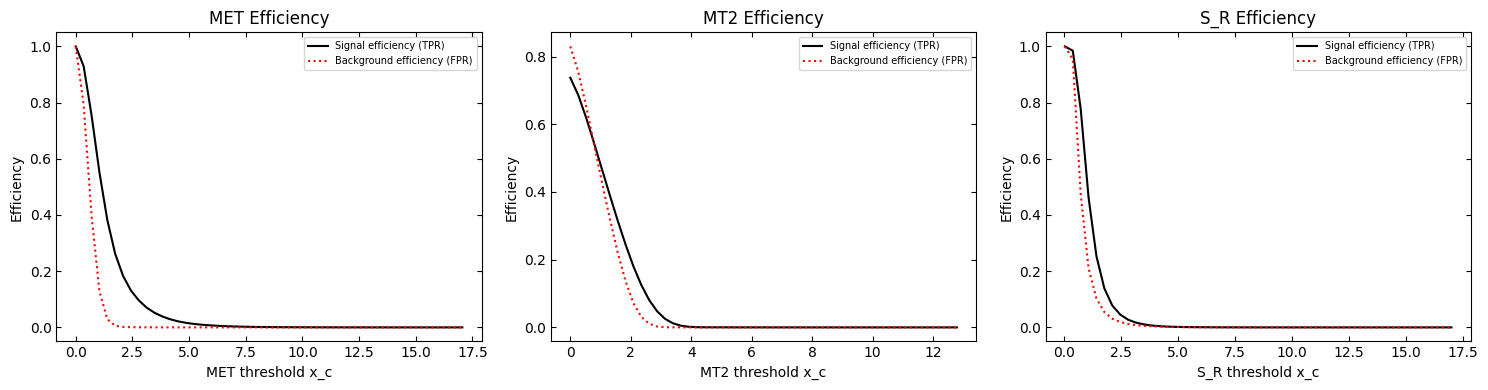

In [58]:
# 5.2
# Threshold ranges
x_c_values_dict = {f: np.linspace(df[f].min(), df[f].max()) for f in features_to_study}

# Efficiency function
def efficiency(signal, background, feature, cut_type, x_c_values):
    tpr = []
    fpr = []
    # Different x_c cut types for testing later
    for x_c in x_c_values:
        # Main one we're focusing on (x > x_c)
        if cut_type == "x > x_c":
            tpr.append((signal[feature] > x_c).mean())
            fpr.append((background[feature] > x_c).mean())

        # Everything else if I want to test it later:
        elif cut_type == "x < x_c":
            tpr.append((signal[feature] < x_c).mean())
            fpr.append((background[feature] < x_c).mean())
        elif cut_type == "|x - mu| > x_c":
            mu = signal[feature].mean()
            tpr.append((abs(signal[feature]-mu) > x_c).mean())
            fpr.append((abs(background[feature]-mu) > x_c).mean())
        elif cut_type == "|x - mu| < x_c":
            mu = signal[feature].mean()
            tpr.append((abs(signal[feature]-mu) < x_c).mean())
            fpr.append((abs(background[feature]-mu) < x_c).mean())
    return np.array(tpr), np.array(fpr)

# Significance calculation
def significance(tpr, fpr, N_S, N_B):
    Np_S = tpr * N_S
    Np_B = fpr * N_B
    # Kept getting errors, most likely from diving by 0? Used an LLM to get this quick fix:
    with np.errstate(divide='ignore', invalid='ignore'):
        sigma = np.where((Np_S + Np_B) > 0, Np_S / np.sqrt(Np_S + Np_B), 0)
    return sigma


# Setting up for multiple plots
fig, axes = plt.subplots(1, len(features_to_study), figsize=(5 * len(features_to_study), 4))
if len(features_to_study) == 1:
    axes = [axes]

# Efficiency plots
for ax, feature in zip(axes, features_to_study):
    x_c_values = x_c_values_dict[feature]
    tpr, fpr = efficiency(signal, background, feature, cut_types[feature], x_c_values)
    
    ax.plot(x_c_values, tpr, label="Signal efficiency (TPR)", color="black")
    ax.plot(x_c_values, fpr, label="Background efficiency (FPR)", color="red", linestyle="dotted")
    
    ax.set_xlabel(f"{feature} threshold x_c")
    ax.set_ylabel("Efficiency")
    ax.set_title(f"{feature} Efficiency")
    ax.tick_params(direction="in", top=True, right=True)
    ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

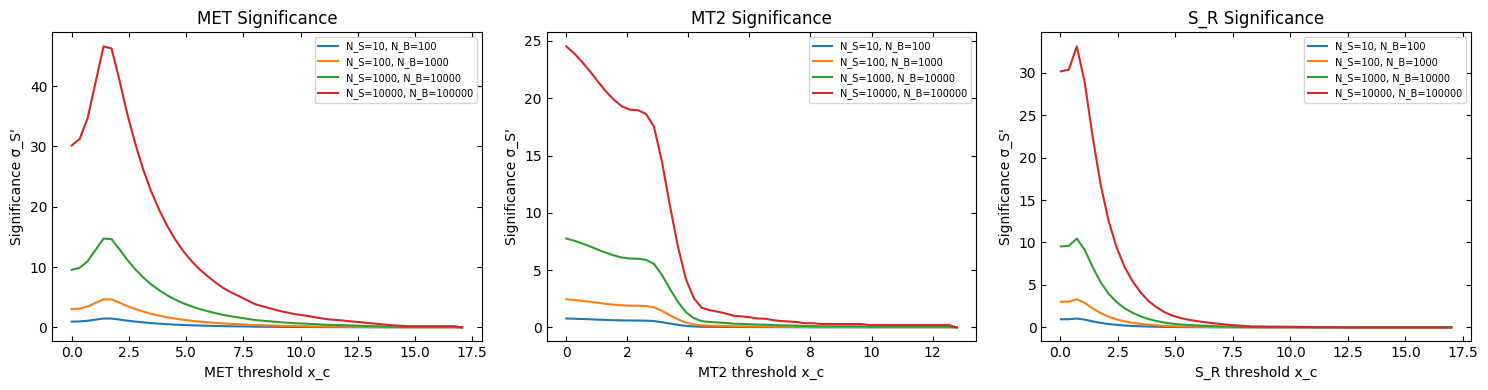

In [59]:
# 5.3
scenarios = [
    (10, 100),
    (100, 1000),
    (1000, 10000),
    (10000, 100000)
]

# Setting up multiple plots
fig, axes = plt.subplots(1, len(features_to_study), figsize=(5 * len(features_to_study), 4))
if len(features_to_study) == 1:
    axes = [axes]

# Signifiance plots
for ax, feature in zip(axes, features_to_study):
    x_c_values = x_c_values_dict[feature]
    tpr, fpr = efficiency(signal, background, feature, cut_types[feature], x_c_values)
    
    for N_S, N_B in scenarios:
        sigma = significance(tpr, fpr, N_S, N_B)
        ax.plot(x_c_values, sigma, label=f"N_S={N_S}, N_B={N_B}")
    
    ax.set_xlabel(f"{feature} threshold x_c")
    ax.set_ylabel("Significance σ_S'")
    ax.set_title(f"{feature} Significance")
    ax.tick_params(direction="in", top=True, right=True)
    ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

## Exercise 6: Cut Flow


### Exercise 6.1

For each above scenario, choose a subset (minumum 3) of observables to use for selections, and values of $x_c$ based on your significance plots (part 3c). 

### Exercise 6.2
Create a "cut-flow" table for each scenario where you successively make the selections on each observable and tabulate $\epsilon_S$, $\epsilon_B$, $N'_S$, $N'_B$, and $\sigma_{S'}$.

### Exercise 6.3
In 3c above you computed the significance for each observable assuming to make no other selections on any other observable. If the variables are correlated, then this assumption can lead to non-optimial results when selecting on multiple variables. By looking at the correlation matrices and your answers to 4b, identify where this effect could be most detrimental to the significance. Attempt to correct the issue by applying the selection in one observable and then optimizing (part 3c) for a second observable. What happens if you change the order of your selection (make selection on second and optimize on first)?




In [65]:
# 6.1
# Still unsure...
# Use MET x_c of 2
# Use MT2 x_c of 3
# Use S_R x_c of 1.2

cut_features = ["MET", "MT2", "R"]
cut_values = {
    "MET": 2,
    "MT2": 3,
    "S_R": 1.2}

In [71]:
# 6.2
def cut_flow_table(sig, bkg, cuts, N_S, N_B):
    results = []
    remaining_sig = sig.copy()
    remaining_bkg = bkg.copy()
    
    for feature, x_c in cuts.items():
        # Apply cut
        mask_sig = remaining_sig[feature] > x_c
        mask_bkg = remaining_bkg[feature] > x_c
        
        remaining_sig = remaining_sig[mask_sig]
        remaining_bkg = remaining_bkg[mask_bkg]
        
        # Efficiencies
        eps_S = mask_sig.mean()
        eps_B = mask_bkg.mean()
        
        # Expected events
        Np_S = eps_S * N_S
        Np_B = eps_B * N_B
        
        # Significance
        sigma = Np_S / np.sqrt(Np_S + Np_B) if (Np_S + Np_B) > 0 else 0
        
        results.append([feature, x_c, eps_S, eps_B, Np_S, Np_B, sigma])
    
    headers = ["Feature", "x_c", "ε_S", "ε_B", "N'_S", "N'_B", "σ_S'"]
    display(HTML(tabulate(results, tablefmt='html', headers=headers, floatfmt=".3f")))
    return remaining_sig, remaining_bkg

# Looping through each scenario
for i, (N_S, N_B) in enumerate(scenarios, start=1):
    print(f"N_S={N_S}, N_B={N_B}")
    remaining_sig, remaining_bkg = cut_flow_table(signal, background, cut_values, N_S, N_B)

N_S=10, N_B=100


Feature,x_c,ε_S,ε_B,N'_S,N'_B,σ_S'
MET,2.000,0.200,0.002,2.001,0.228,1.340
MT2,3.000,0.089,0.045,0.894,4.531,0.384
S_R,1.200,0.516,0.286,5.165,28.571,0.889


N_S=100, N_B=1000


Feature,x_c,ε_S,ε_B,N'_S,N'_B,σ_S'
MET,2.000,0.200,0.002,20.015,2.283,4.239
MT2,3.000,0.089,0.045,8.942,45.307,1.214
S_R,1.200,0.516,0.286,51.645,285.714,2.812


N_S=1000, N_B=10000


Feature,x_c,ε_S,ε_B,N'_S,N'_B,σ_S'
MET,2.000,0.200,0.002,200.148,22.825,13.404
MT2,3.000,0.089,0.045,89.423,453.074,3.839
S_R,1.200,0.516,0.286,516.451,2857.143,8.892


N_S=10000, N_B=100000


Feature,x_c,ε_S,ε_B,N'_S,N'_B,σ_S'
MET,2.000,0.200,0.002,2001.483,228.251,42.386
MT2,3.000,0.089,0.045,894.231,4530.744,12.141
S_R,1.200,0.516,0.286,5164.514,28571.429,28.118


In [72]:
# 6.3
# Reversing order
cut_values_reversed = {k: cut_values[k] for k in reversed(cut_values)}
cut_flow_table(signal, background, cut_values_reversed, N_S, N_B)

Feature,x_c,ε_S,ε_B,N'_S,N'_B,σ_S'
S_R,1.200,0.367,0.158,3666.514,15795.461,26.282
MT2,3.000,0.041,0.002,413.668,205.766,16.621
MET,2.000,0.609,0.091,6094.334,9090.909,49.456


(        signal    l_1_pT   l_1_eta   l_1_phi    l_2_pT   l_2_eta   l_2_phi  \
 44         1.0  1.873410  0.160715 -0.047229  1.393590 -0.764182  1.234850   
 87         1.0  1.279494 -0.654278 -1.570103  1.558007  0.156796 -0.404468   
 248        1.0  1.412390 -0.149049 -0.801141  0.537965  1.958318 -1.533865   
 355        1.0  1.618450  0.475777 -0.771107  0.474357 -1.036634 -1.372080   
 499        1.0  3.413133  0.945585 -1.014896  1.553204  0.817129  0.300755   
 ...        ...       ...       ...       ...       ...       ...       ...   
 499087     1.0  2.700655  0.753729  1.484860  0.468504  1.820922  0.745830   
 499109     1.0  1.819062 -0.285453 -0.245710  1.958713  0.288426  1.197143   
 499766     1.0  1.820411 -0.015112 -1.291332  0.918552  0.444596  0.885194   
 499805     1.0  0.847713  0.496682  0.543434  1.209855  0.232333 -0.673801   
 499934     1.0  1.006281 -1.686961 -0.245206  1.023358 -0.422303 -1.355666   
 
              MET   MET_phi   MET_rel  axial_MET  

## Exercise 7: ROC Curves

### Exercise 7.1
For the top 3 observables you identified earlier, create one figure overlaying the Reciever Operating Characteristic (ROC) curves for the 3 observables. Compute the area under the curves and report it in the legend of the figure.

### Exercise 7.2
Write a function that you can use to quickly create the figure in part a with other observables and different conditions. Note that you will likely revise this function as you do the remainder of the lab.

### Exercise 7.3
Use the function from part b to compare the ROC curves for the successive selections in lab 3, exercise 4. Specifically, plot the ROC curve after each selection.

### Exercise 7.4
Use your function and appropriate example to demonstrate the effect (if any) of changing order of the successive selections.



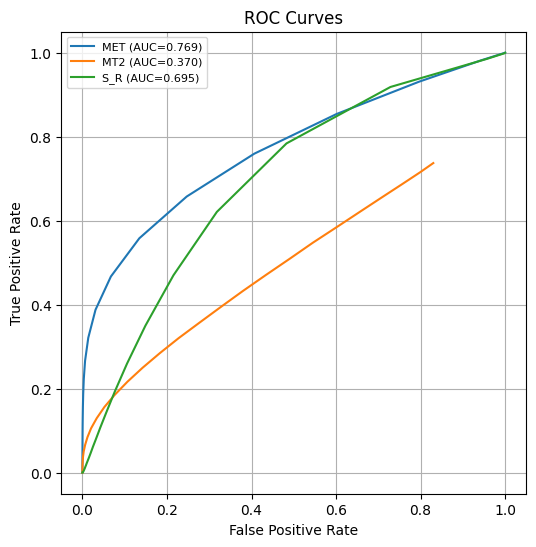

In [92]:
# [!!!] Use an LLM for big chunks of Exercise 7
# 7.1
from sklearn.metrics import auc

def roc_curve_plot(sig, bkg, features):
    plt.figure(figsize=(6,6))
    
    for feature in features:
        # Thresholds
        # np.linspace generates 100 equally spaced values between min and max value of the feature across both signal and background
        x_vals = np.linspace(min(sig[feature].min(), bkg[feature].min()),
                             max(sig[feature].max(), bkg[feature].max()), 100)
        # Computes TPR and FPR at each threshold
        tpr, fpr = efficiency(sig, bkg, feature, "x > x_c", x_vals)
        # Area under the curve
        roc_auc = auc(fpr, tpr)
        
        plt.plot(fpr, tpr, label=f"{feature} (AUC={roc_auc:.3f})")
    
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curves")
    plt.legend(fontsize=8)
    plt.grid(True)
    plt.show()

roc_curve_plot(signal, background, ["MET", "MT2", "S_R"])

In [79]:
# 7.2
def plot_roc(sig, bkg, features, cut_type="x > x_c", title="ROC Curves"):
    plt.figure(figsize=(6,6))
    
    for feature in features:
        x_vals = np.linspace(min(sig[feature].min(), bkg[feature].min()),
                             max(sig[feature].max(), bkg[feature].max()), 100)
        tpr, fpr = efficiency(sig, bkg, feature, cut_type, x_vals)
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{feature} (AUC={roc_auc:.3f})")
    
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend(fontsize=8)
    plt.grid(True)
    plt.show()

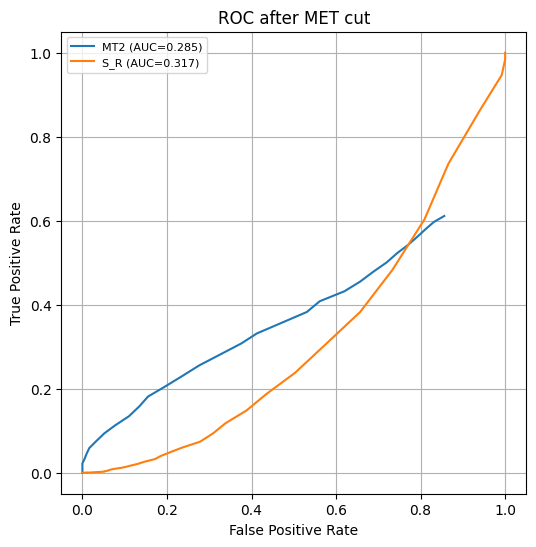

In [81]:
# 7.3 & 7.4
# ...Lab 3 exercise 4??? (Using a histogram function to create a text-based "graph")
# Use MET x_c of 2
# Use MT2 x_c of 3
# Use S_R x_c of 1.2

# Applying MET cut first
mask_sig = signal["MET"] > 2
mask_bkg = background["MET"] > 2
sig_remain = signal[mask_sig]
bkg_remain = background[mask_bkg]

# ROC for remaining events
plot_roc(sig_remain, bkg_remain, ["MT2", "S_R"], title="ROC after MET cut")

## Exercise 8: Linear Discriminant

### Exercise 8.1

Using numpy, compute the between-class $\bf{S}_B$ and within-class $\bf{S}_W$ covariance matrices defined as:

$$
\bf{S}_B = (\bf{m_2}-\bf{m_1})(\bf{m_2}-\bf{m_1})^T \\
$$
$$
\bf{S}_W = \sum_{i=1,2} \sum_{n=1}^{l_i} (\bf{x}_n^i - \bf{m}_i) (\bf{x}_n^i - \bf{m}_i)^T
$$

where $\bf{m_i}$ are the vectors containing the means for category 1 and 2, here defined as signal and background. Here $\bf{x}_n^i$ is the vector containing the observables for the $n$th example event in category $i$.

### Exercise 8.1

Compute the linear coefficients $\bf{w} = \bf{S_W}^{-1}(\bf{m_2}-\bf{m_1})$. Compare the histogram of the distribution of $F_n^i=\bf{w}^T\bf{x}_n^i$ for the two categories.

### Exercise 8.1

Draw the ROC curve for $F_n$. 

### Exercise 8.1

What is the maximal significance you can obtain in the scenarios in exercise 5? 

In [91]:
# [!!!] Use an LLM for big chunks of Exercise 8
# Part a)
# Selecting features
features = ["MET", "MT2", "S_R"]

# Signal and background as numpy arrays
X_sig = signal[features].to_numpy()
X_bkg = background[features].to_numpy()

# Mean vector of signal
m1 = np.mean(X_sig, axis=0)
# Mean vector of background
m2 = np.mean(X_bkg, axis=0)

# Computing S_W
S_W = np.zeros((len(features), len(features)))

for X, m in [(X_sig, m1), (X_bkg, m2)]:
    for x_n in X:
        # Column vector
        diff = (x_n - m).reshape(-1,1)
        # Outer product
        S_W += diff @ diff.T

# Computing S_B
diff_mean = (m2 - m1).reshape(-1,1)
S_B = diff_mean @ diff_mean.T

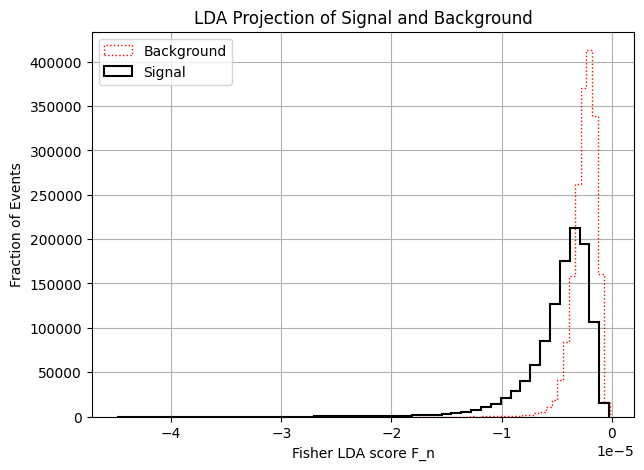

In [84]:
# Part b)
# Computing w
w = np.linalg.inv(S_W) @ (m2 - m1)

# Projecting data on w
# shape (n_sig,)
F_sig = X_sig @ w
# shape (n_bkg,)
F_bkg = X_bkg @ w

# Plotting histogram
plt.figure(figsize=(7,5))
plt.hist(F_bkg, bins=50, density=True, histtype="step", color="red", linestyle="dotted", label="Background")
plt.hist(F_sig, bins=50, density=True, histtype="step", color="black", linewidth=1.5, label="Signal")
plt.xlabel("Fisher LDA score F_n")
plt.ylabel("Fraction of Events")
plt.legend()
plt.title("LDA Projection of Signal and Background")
plt.grid(True)
plt.show()

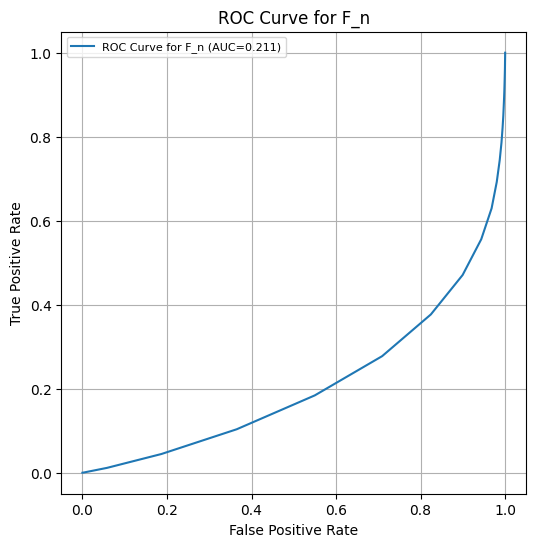

In [97]:
# Part c)
# Modified function from earlier for Exercise 8
def plot_roc_fn(F_sig, F_bkg, title="ROC Curve"):
    plt.figure(figsize=(6,6))
    
    # Computing thresholds along projected values
    x_vals = np.linspace(min(F_sig.min(), F_bkg.min()), max(F_sig.max(), F_bkg.max()), 100)
    tpr = [(F_sig > x).mean() for x in x_vals]
    fpr = [(F_bkg > x).mean() for x in x_vals]
    roc_auc = auc(fpr, tpr)

    # Labelling
    plt.plot(fpr, tpr, label=f"ROC Curve for F_n (AUC={roc_auc:.3f})")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend(fontsize=8)
    plt.grid(True)
    plt.show()

plot_roc_fn(F_sig, F_bkg, title="ROC Curve for F_n")

In [99]:
# Part d)
def max_significance(F_sig, F_bkg, N_S, N_B):
    # Generating 200 evenly spaced thresholds between min and max
    thresholds = np.linspace(min(F_sig.min(), F_bkg.min()),
                             max(F_sig.max(), F_bkg.max()), 200)
    sigs = []
    # For threshold x_c...
    for x_c in thresholds:
        # Fraction of signal events above threshold
        eps_S = (F_sig > x_c).mean()
        # Fraction of background events above threshold
        eps_B = (F_bkg > x_c).mean()
        # Expected number of signal events passing the cut
        Np_S = eps_S * N_S
        # Expected number of background events passing the cut
        Np_B = eps_B * N_B
        # Significance from Exercise 5
        sigma = Np_S / np.sqrt(Np_S + Np_B) if (Np_S + Np_B) > 0 else 0
        sigs.append(sigma)
    # Returning all thresholds and corresponding significances
    return thresholds, np.array(sigs)

# Looping through each scenario to find significance levels
for N_S, N_B in scenarios:
    # Calling max_significance for each scenario
    thresholds, sigs = max_significance(F_sig, F_bkg, N_S, N_B)
    max_sigma = sigs.max()
    best_xc = thresholds[sigs.argmax()]
    print(f"Scenario N_S={N_S}, N_B={N_B}: Max significance σ_S' = {max_sigma:.3f} at x_c = {best_xc:.3f}")

Scenario N_S=10, N_B=100: Max significance σ_S' = 0.953 at x_c = -0.000
Scenario N_S=100, N_B=1000: Max significance σ_S' = 3.015 at x_c = -0.000
Scenario N_S=1000, N_B=10000: Max significance σ_S' = 9.535 at x_c = -0.000
Scenario N_S=10000, N_B=100000: Max significance σ_S' = 30.151 at x_c = -0.000


In [ ]:
# [!!!] Note: Used LLM to help with following logic and coding. Pretty something here isn't quite right, but I've decided to not spend any more time on the assignment